<a href="https://colab.research.google.com/github/ucaokylong/Some_small_projects/blob/main/Segmentation_for_Kvasir_SEG_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import copy
import torch
import random
import numpy as np
from PIL import Image
from glob import glob
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
# Tải dữ liệu
!gdown 1vmtDOK6BQMfjoZZVZcn8mOPfpwsGWlym
!unzip -q Kvasir-SEG.zip

Downloading...
From (original): https://drive.google.com/uc?id=1vmtDOK6BQMfjoZZVZcn8mOPfpwsGWlym
From (redirected): https://drive.google.com/uc?id=1vmtDOK6BQMfjoZZVZcn8mOPfpwsGWlym&confirm=t&uuid=bc31ba29-6a36-47b9-8bbb-d65f4e8b604b
To: /content/Kvasir-SEG.zip
100% 151M/151M [00:03<00:00, 46.0MB/s]


In [3]:
# Tạo đường dẫn
ROOT_PATH = '/content/Kvasir-SEG/Kvasir-SEG'
images_path = os.path.join(ROOT_PATH, 'images')
masks_path = os.path.join(ROOT_PATH, 'masks')

In [4]:
img_size = (128, 128)

# Định nghĩa các biến đổi hình ảnh
image_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

def mask_transform(mask):
    mask = transforms.Resize(img_size, interpolation=Image.NEAREST)(mask)
    mask = transforms.functional.pil_to_tensor(mask).squeeze(0)
    mask = mask / 255.0
    mask = torch.round(mask).long()
    return mask

In [5]:
def elastic_transform(image, mask, alpha_affine=10):
    random_state = np.random.RandomState(None)
    shape = image.size[::-1]  # (H, W)

    center_square = np.float32(shape) // 2
    square_size = min(shape) // 3
    pts1 = np.float32([center_square + square_size,
                       [center_square[0] + square_size, center_square[1] - square_size],
                       center_square - square_size])
    pts2 = pts1 + random_state.uniform(-alpha_affine, alpha_affine, size=pts1.shape).astype(np.float32)

    M = cv2.getAffineTransform(pts1, pts2)
    image = cv2.warpAffine(np.array(image), M, shape[::-1], borderMode=cv2.BORDER_REFLECT_101)
    mask = cv2.warpAffine(np.array(mask), M, shape[::-1], borderMode=cv2.BORDER_REFLECT_101)

    return Image.fromarray(image), Image.fromarray(mask)

def hflip_transform(image, mask):
    return image.transpose(Image.FLIP_LEFT_RIGHT), mask.transpose(Image.FLIP_LEFT_RIGHT)

def vflip_transform(image, mask):
    return image.transpose(Image.FLIP_TOP_BOTTOM), mask.transpose(Image.FLIP_TOP_BOTTOM)

def flip_transform(image, mask):
    return image.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM), mask.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM)


In [7]:
# Xây dựng PyTorch Dataset
class KvasirDatasetAugmented(Dataset):
    def __init__(self, images_path, masks_path, transform=None, target_transform=None, augmentations=None):
        self.images_path = sorted(os.listdir(images_path))
        self.masks_path = sorted(os.listdir(masks_path))
        self.images_dir = images_path
        self.masks_dir = masks_path
        self.transform = transform
        self.target_transform = target_transform
        self.augmentations = augmentations if augmentations else []

        self.data = self._generate_augmented_data()

    def _generate_augmented_data(self):
        augmented_data = []
        for img_file, mask_file in zip(self.images_path, self.masks_path):
            img_path = os.path.join(self.images_dir, img_file)
            mask_path = os.path.join(self.masks_dir, mask_file)

            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")

            augmented_data.append((image, mask))

            for aug_func in self.augmentations:
                aug_image, aug_mask = aug_func(image, mask)
                augmented_data.append((aug_image, aug_mask))

        return augmented_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, mask = self.data[idx]

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            mask = self.target_transform(mask)

        return image, mask


In [8]:
# Khởi tạo dataset với augmentation
augmentations = [elastic_transform, hflip_transform, vflip_transform, flip_transform]
dataset = KvasirDatasetAugmented(images_path, masks_path, transform=image_transform, target_transform=mask_transform, augmentations=augmentations)

# Tiến hành phân chia dữ liệu
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])


In [21]:
# Khai báo PyTorch Dataloader
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [25]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.MaxPool2d(2),
            ConvBlock(in_channels, out_channels)
        )

    def forward(self, x):
        x = self.encoder(x)
        return x

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.conv_block = ConvBlock(2 * out_channels, out_channels)  # Điều chỉnh số kênh đầu vào

    def forward(self, x1, x2):
        x1 = self.conv_trans(x1)
        x = torch.cat([x2, x1], dim=1)
        x = self.conv_block(x)
        return x


class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.in_conv = ConvBlock(n_channels, 64)

        self.enc_1 = Encoder(64, 128)
        self.enc_2 = Encoder(128, 256)
        self.enc_3 = Encoder(256, 512)
        self.enc_4 = Encoder(512, 1024)

        self.dec_1 = Decoder(1024, 512)
        self.dec_2 = Decoder(512, 256)
        self.dec_3 = Decoder(256, 128)
        self.dec_4 = Decoder(128, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)

        x2 = self.enc_1(x1)
        x3 = self.enc_2(x2)
        x4 = self.enc_3(x3)
        x5 = self.enc_4(x4)

        x = self.dec_1(x5, x4)
        x = self.dec_2(x, x3)
        x = self.dec_3(x, x2)
        x = self.dec_4(x, x1)

        x = self.out_conv(x)
        return x


In [26]:
def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

    test_loss = test_loss / len(test_loader)
    return test_loss


In [27]:
# Khai báo các tham số cho Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(n_channels=1, n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [28]:
# Model Training và Evaluation
best_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(30):
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss = train_loss / len(train_loader)

    val_loss = evaluate(model, val_loader, criterion)

    if val_loss < best_loss:
        best_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Train Loss: 0.3395, Val Loss: 0.4671
Epoch 2, Train Loss: 0.2991, Val Loss: 0.3110
Epoch 3, Train Loss: 0.2813, Val Loss: 0.3534
Epoch 4, Train Loss: 0.2665, Val Loss: 0.3433
Epoch 5, Train Loss: 0.2510, Val Loss: 0.3270
Epoch 6, Train Loss: 0.2343, Val Loss: 0.2456
Epoch 7, Train Loss: 0.2138, Val Loss: 0.3033
Epoch 8, Train Loss: 0.1905, Val Loss: 0.2126
Epoch 9, Train Loss: 0.1688, Val Loss: 0.2244
Epoch 10, Train Loss: 0.1486, Val Loss: 0.2429
Epoch 11, Train Loss: 0.1366, Val Loss: 0.1771
Epoch 12, Train Loss: 0.1200, Val Loss: 0.1797
Epoch 13, Train Loss: 0.1057, Val Loss: 0.1436
Epoch 14, Train Loss: 0.0903, Val Loss: 0.1542
Epoch 15, Train Loss: 0.0792, Val Loss: 0.1392
Epoch 16, Train Loss: 0.0760, Val Loss: 0.1228
Epoch 17, Train Loss: 0.0651, Val Loss: 0.1274
Epoch 18, Train Loss: 0.0591, Val Loss: 0.1580
Epoch 19, Train Loss: 0.0558, Val Loss: 0.1178
Epoch 20, Train Loss: 0.0541, Val Loss: 0.1625
Epoch 21, Train Loss: 0.0526, Val Loss: 0.1488
Epoch 22, Train Loss: 

In [29]:
# Xây dựng hàm để hiển thị kết quả dự đoán
def display_prediction(model, image, ground_truth, device):
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        prediction = model(image)
        prediction = torch.argmax(prediction, dim=1).squeeze(0).cpu().numpy()

    image_np = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    ground_truth_np = ground_truth.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(image_np, cmap='gray')
    axs[0].set_title("Input Image")
    axs[1].imshow(ground_truth_np, cmap='gray')
    axs[1].set_title("Ground Truth")
    axs[2].imshow(prediction, cmap='gray')
    axs[2].set_title("Prediction")
    for ax in axs:
        ax.axis("off")
    plt.show()

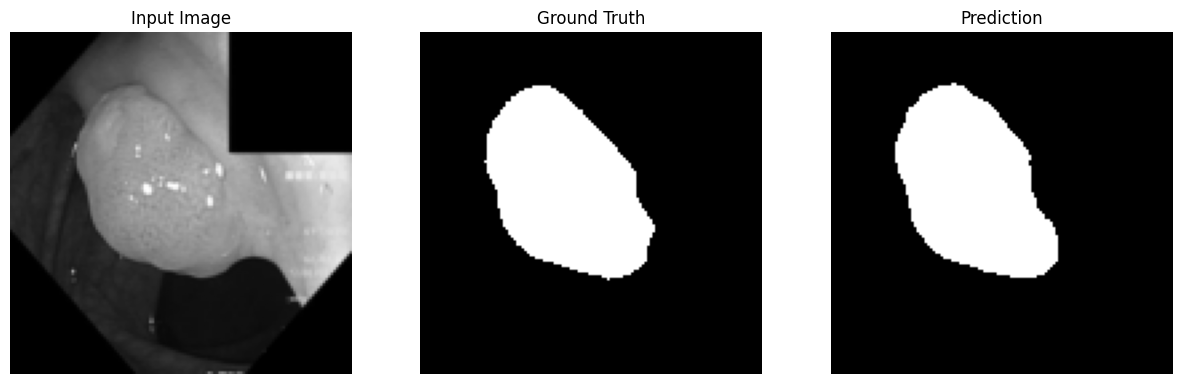

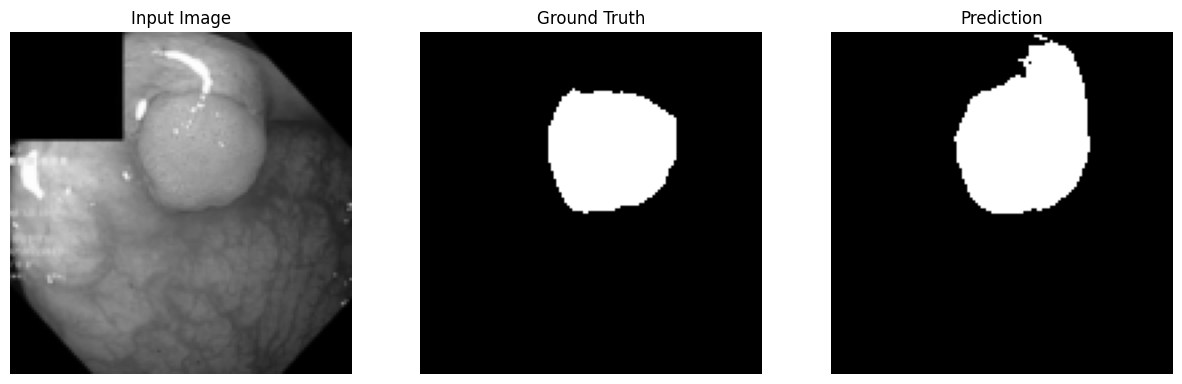

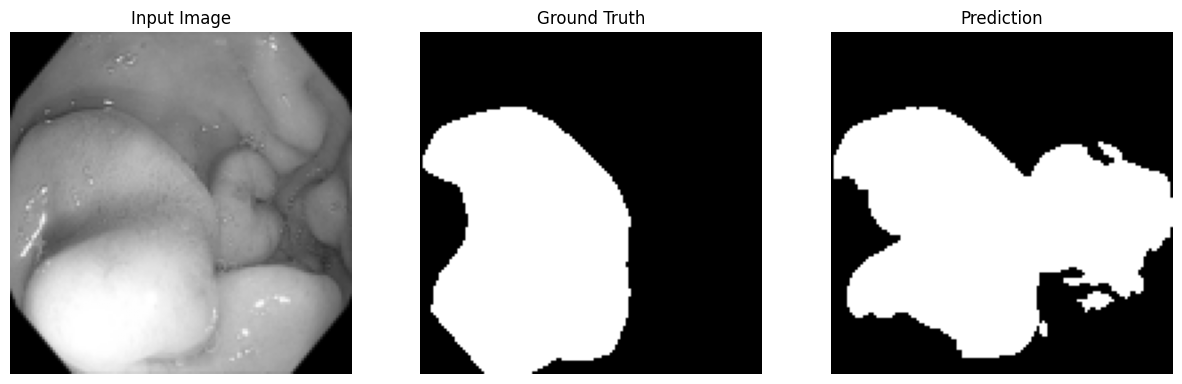

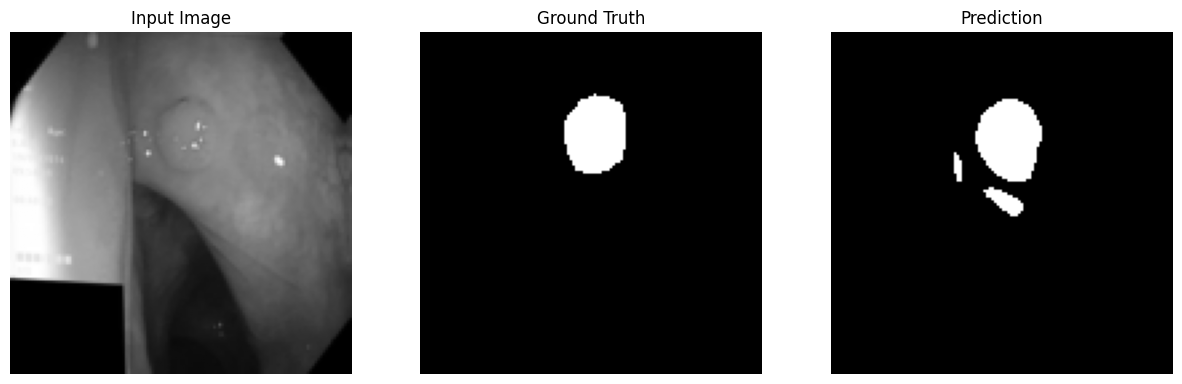

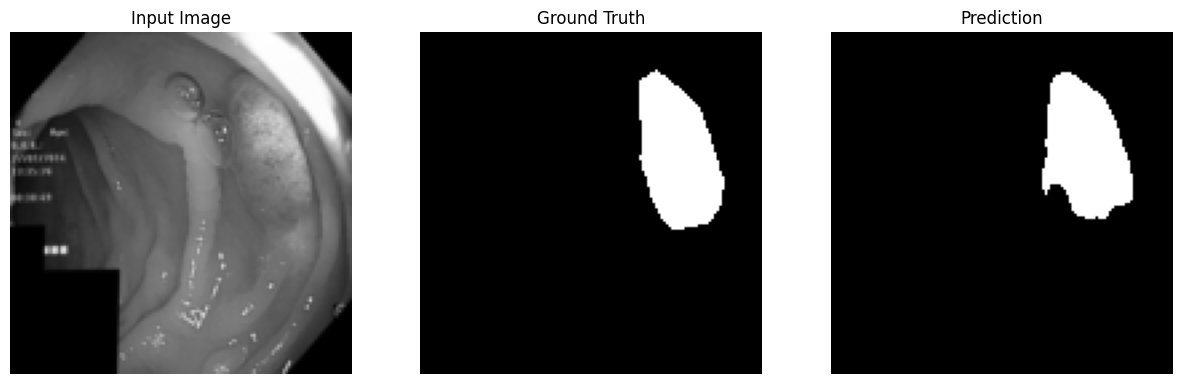

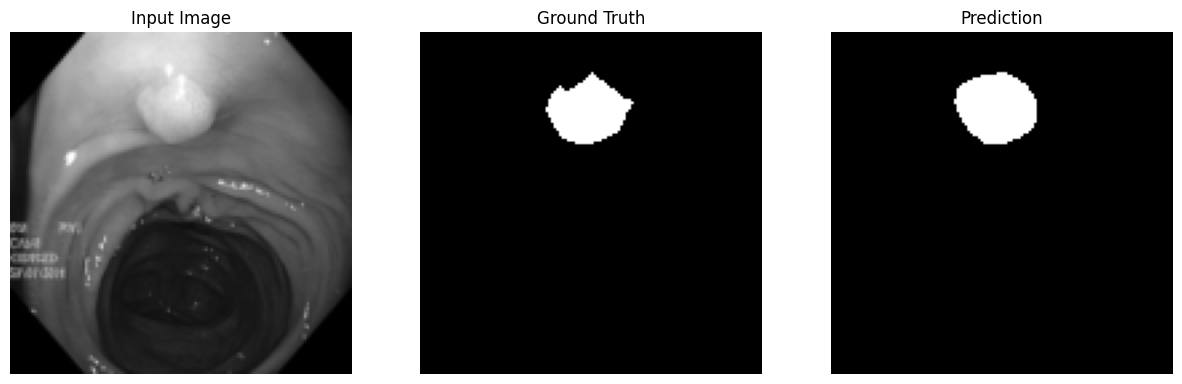

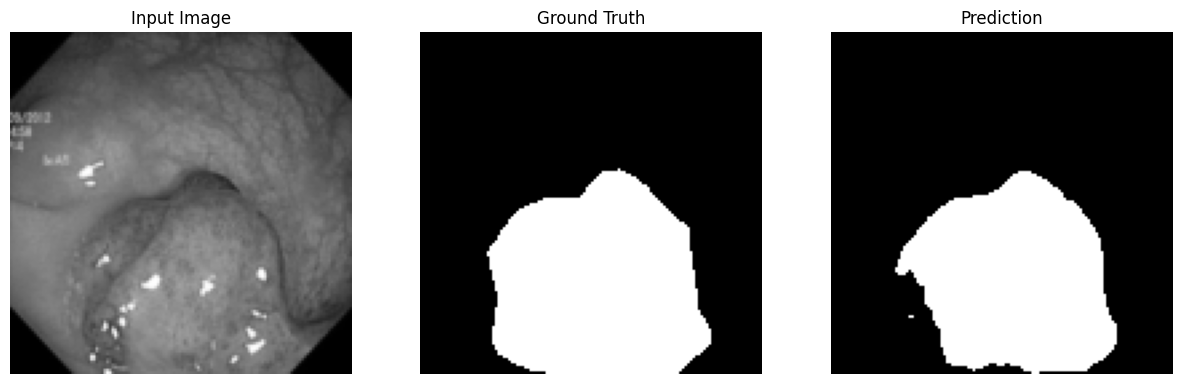

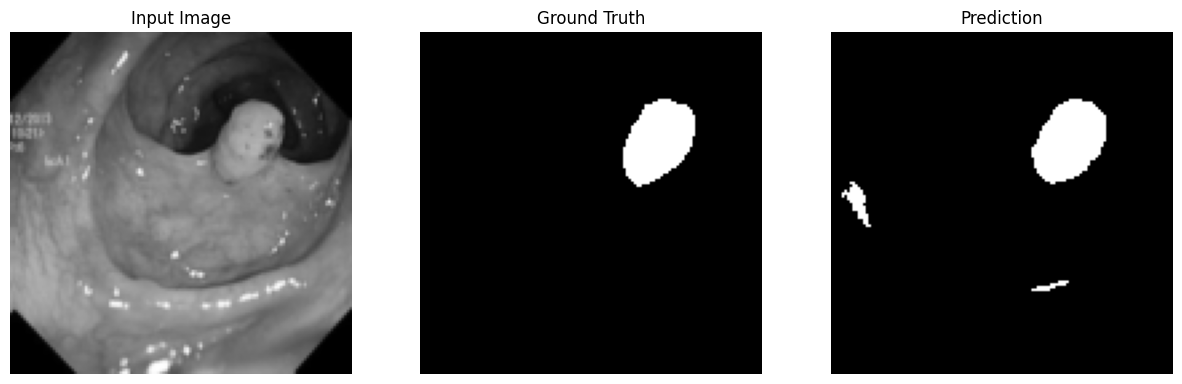

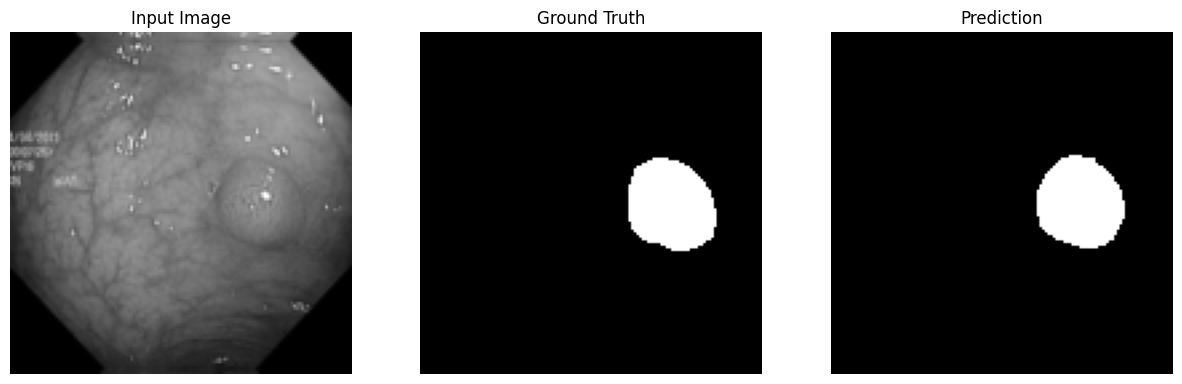

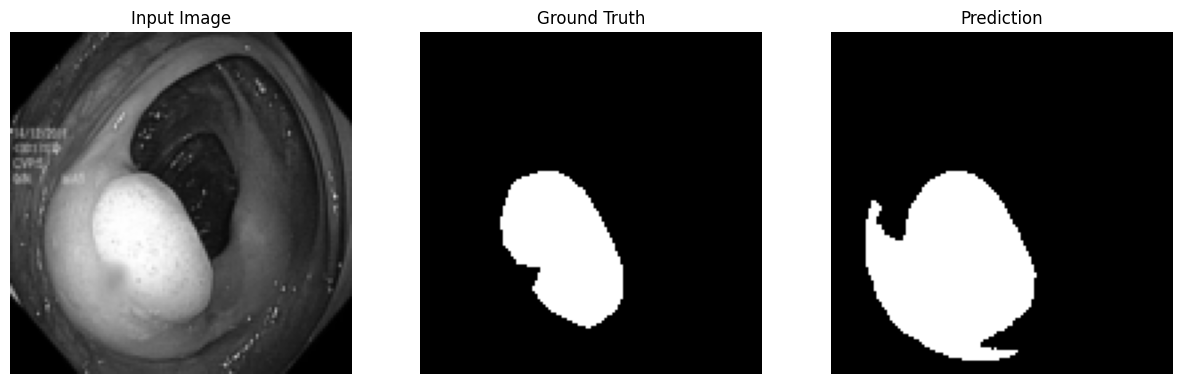

In [30]:

model.load_state_dict(best_model_wts)

n_test_points = 10
model.eval()

test_samples = [test_dataset[i] for i in range(n_test_points)]

for i in range(n_test_points):
    img, gt = test_samples[i]
    display_prediction(model, img, gt, device)